In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [158]:
data = pd.read_csv('Churn_Modelling.csv')

In [160]:
data.sample(8)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3475,3476,15770554,Fraser,769,France,Male,31,4,61297.05,2,1,1,7118.02,0
5793,5794,15784890,McKenzie,763,Spain,Female,32,8,0.00,2,1,0,16725.53,0
7275,7276,15642336,Shaw,669,France,Female,42,9,0.00,2,0,0,135630.32,0
3500,3501,15675675,Slate,850,France,Female,32,5,106290.64,1,1,0,121982.73,0
7339,7340,15670646,Moore,499,Spain,Female,42,0,147187.84,1,1,1,14868.94,1
8399,8400,15749365,Earle,543,France,Female,34,8,0.00,2,0,1,145601.80,0
5425,5426,15595153,Tucker,644,Germany,Female,44,8,106022.73,2,0,0,148727.42,0
6668,6669,15793671,Watt,606,France,Male,34,5,0.00,1,1,0,161971.42,0


In [162]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [164]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [166]:
data = data.drop(['RowNumber','CustomerId','Surname'],axis = 1)

In [168]:
data.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7329,501,France,Female,34,5,0.00,1,1,0,27380.99,0
7947,639,Spain,Female,35,5,136526.26,2,1,0,59653.03,0
1429,601,France,Female,26,8,78892.23,1,1,1,23703.52,0
7849,643,Germany,Male,41,7,154902.66,1,1,1,49667.28,0
9259,800,France,Female,40,3,75893.11,2,1,0,132562.23,0


In [170]:
data.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [172]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [174]:
data.shape

(10000, 11)

<Axes: xlabel='Balance'>

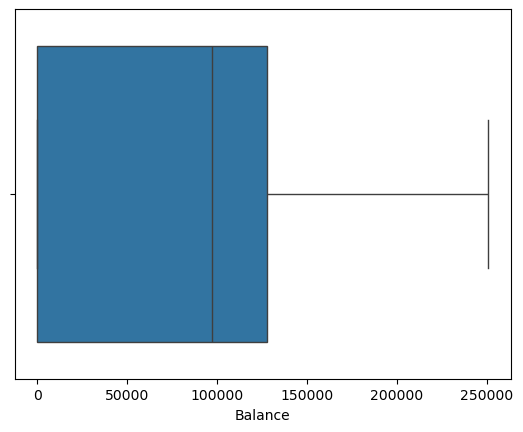

In [176]:
sns.boxplot(x= data['Balance'])


<Axes: xlabel='EstimatedSalary'>

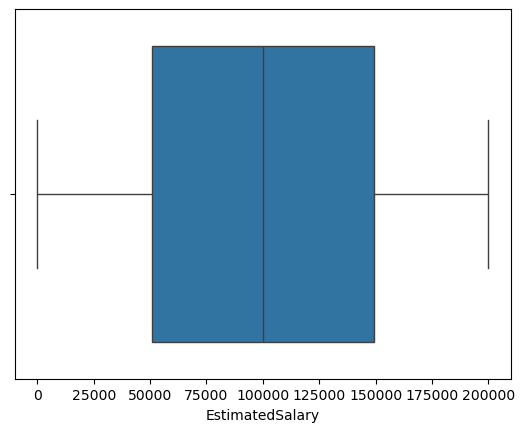

In [178]:
sns.boxplot(x= data['EstimatedSalary'])

<Axes: xlabel='CreditScore'>

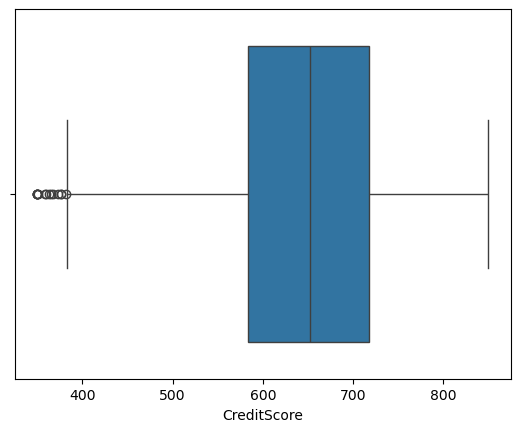

In [180]:
sns.boxplot(x= data['CreditScore'])

In [182]:
(data['CreditScore']<400).mean()*100

0.19

In [184]:
data.shape

(10000, 11)

In [186]:
data =data[data['CreditScore'] >= 400]

In [188]:
data.shape

(9981, 11)

<Axes: xlabel='Age'>

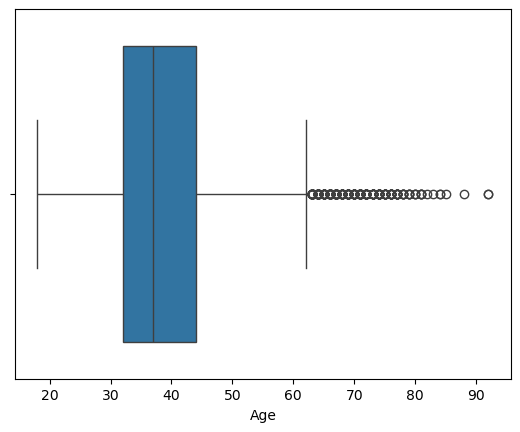

In [190]:
sns.boxplot(x= data['Age'])

<Axes: xlabel='Tenure'>

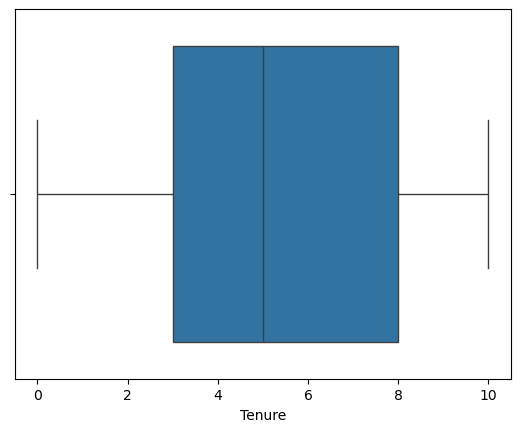

In [192]:
sns.boxplot(x=data['Tenure'])

C:\Users\Umashree.K.dandin\AppData\Local\Temp\ipykernel_12628\2130793797.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = data['Age'])


<Axes: ylabel='Density'>

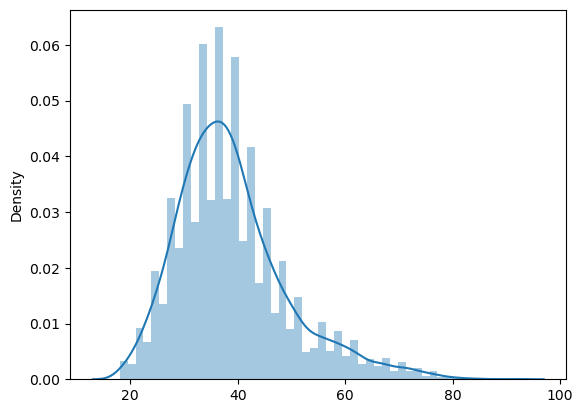

In [194]:
sns.distplot(x = data['Age'])

<Axes: xlabel='Exited', ylabel='count'>

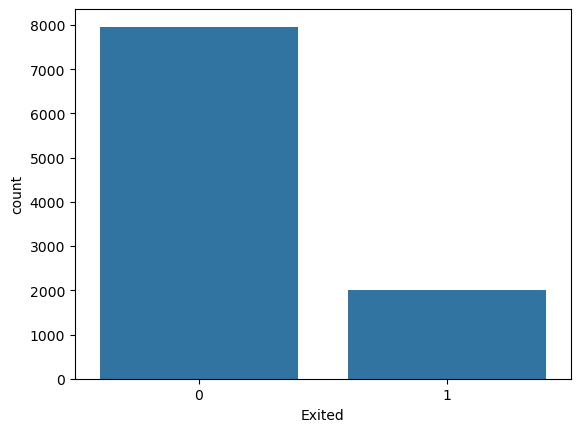

In [196]:
sns.countplot(x=data['Exited'])

In [212]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,classification_report

In [296]:
transformer = ColumnTransformer([
    ('scaler',StandardScaler(),['Balance','EstimatedSalary']),
    ('Encoder',OneHotEncoder(drop ='first',handle_unknown = 'ignore'),['Gender','Geography'])   
])

In [298]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [300]:
print(x.shape)
print(y.shape)

(9981, 10)
(9981,)


In [302]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state = 10)

In [333]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [578]:
pipeline = Pipeline([
    ('preprocessor',transformer),
    #('classifier',SVC(C=1,kernel = 'rbf',gamma = 'auto'))
    ('classifier',DecisionTreeClassifier(criterion = 'entropy',min_samples_leaf = 10,min_samples_split = 20,max_depth =8)) # Accuracy is 76 (gini) and 77 ( entropy)
])

In [580]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['Balance',
                                                   'EstimatedSalary']),
                                                 ('Encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Geography'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=8,
                                        min_samples_leaf=10,
                                        min_samples_split=20))])

In [582]:
y_pred = pipeline.predict(x_test)

In [584]:
accuracy_score(y_test,y_pred)

0.7961942914371557